In [65]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [66]:
# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head(10) #display first 10 rows of data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [67]:
#Show names of dataset columns
columns=df.columns
print("Column names:")
print("-------------")
for i,j in enumerate(columns):
    print(f"{i}. {j}")

Column names:
-------------
0. customerID
1. gender
2. SeniorCitizen
3. Partner
4. Dependents
5. tenure
6. PhoneService
7. MultipleLines
8. InternetService
9. OnlineSecurity
10. OnlineBackup
11. DeviceProtection
12. TechSupport
13. StreamingTV
14. StreamingMovies
15. Contract
16. PaperlessBilling
17. PaymentMethod
18. MonthlyCharges
19. TotalCharges
20. Churn


In [68]:
#show data types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [69]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan) #convert empty cells to NaN values
df['TotalCharges'] = df['TotalCharges'].astype(float) #convert TotalCharges column to float type

In [70]:
#look for missing values and replace them with NaN
for i in columns:
    df[i] = df[i].replace(' ', np.nan)

In [71]:
print(df.isnull().sum())
#Only TotalCharges has missing values

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [72]:
df.dropna(inplace=True) #removes all rows with missing data

In [73]:
df=df.drop('customerID', axis=1) #drop the customerID column

In [74]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)
#replace 'Yes' with 1
#replace 'No' with 0
#change Churn column to an integer type

C:\Users\ivano\AppData\Local\Temp\ipykernel_23824\3656806837.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)


In [75]:
'''titanic_df = pd.get_dummies(titanic_df, prefix="Sex", columns=["Sex"])
titanic_df = pd.get_dummies(titanic_df, prefix="Embarked", columns=["Embarked"])
titanic_df.drop("Sex_female", axis=1, inplace=True)'''

'titanic_df = pd.get_dummies(titanic_df, prefix="Sex", columns=["Sex"])\ntitanic_df = pd.get_dummies(titanic_df, prefix="Embarked", columns=["Embarked"])\ntitanic_df.drop("Sex_female", axis=1, inplace=True)'

In [76]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [77]:
#check unique values in categorical variables
print("unique variables")
print(f'Contract: {df['Contract'].unique()}')
print(f'InternetService: {df['InternetService'].unique()}')
print(f'gender: {df['gender'].unique()}')
print(f'MultipleLines: {df['MultipleLines'].unique()}')
print(f'PaymentMethod: {df['PaymentMethod'].unique()}')

unique variables
Contract: ['Month-to-month' 'One year' 'Two year']
InternetService: ['DSL' 'Fiber optic' 'No']
gender: ['Female' 'Male']
MultipleLines: ['No phone service' 'No' 'Yes']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [78]:

columns_to_change = [
    'Contract', 
    'InternetService', 
    'gender', 
    'MultipleLines', 
    'PaymentMethod'
]
df_dummies= pd.get_dummies(df[columns_to_change], drop_first=True) #create dummie columns and delete first one to avoid variable trap

df = df.drop(columns=columns_to_change) #drop original columns from the dataset

telecom_cust_dummies = pd.concat([df_dummies, df], axis=1) # add the new dummy columns to the original dataset df


In [79]:
pd.set_option('display.max_columns', None)
telecom_cust_dummies.head()

,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,True,False,False,True,False,0,Yes,No,1,No,No,Yes,No,No,No,No,Yes,29.85,29.85,0
1,True,False,False,False,True,False,False,False,False,True,0,No,No,34,Yes,Yes,No,Yes,No,No,No,No,56.95,1889.50,0
2,False,False,False,False,True,False,False,False,False,True,0,No,No,2,Yes,Yes,Yes,No,No,No,No,Yes,53.85,108.15,1
3,True,False,False,False,True,True,False,False,False,False,0,No,No,45,No,Yes,No,Yes,Yes,No,No,No,42.30,1840.75,0
4,False,False,True,False,False,False,False,False,True,False,0,No,No,2,Yes,No,No,No,No,No,No,Yes,70.70,151.65,1


In [80]:

telecom_cust_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Contract_One year                      7032 non-null   bool   
 1   Contract_Two year                      7032 non-null   bool   
 2   InternetService_Fiber optic            7032 non-null   bool   
 3   InternetService_No                     7032 non-null   bool   
 4   gender_Male                            7032 non-null   bool   
 5   MultipleLines_No phone service         7032 non-null   bool   
 6   MultipleLines_Yes                      7032 non-null   bool   
 7   PaymentMethod_Credit card (automatic)  7032 non-null   bool   
 8   PaymentMethod_Electronic check         7032 non-null   bool   
 9   PaymentMethod_Mailed check             7032 non-null   bool   
 10  SeniorCitizen                          7032 non-null   int64  
 11  Partner  

In [81]:
replacement_map = {'Yes': 1, 'No': 0, 'False': 0, 'No internet service': 0}

list_of_columns=telecom_cust_dummies.columns
for i in list_of_columns:
    if telecom_cust_dummies[i].dtype == 'object' or telecom_cust_dummies[i].dtype == 'bool':
        telecom_cust_dummies[i] = (
            telecom_cust_dummies[i]
            .replace(replacement_map)
            .astype(int)
        )



C:\Users\ivano\AppData\Local\Temp\ipykernel_23824\1755701482.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(replacement_map)
C:\Users\ivano\AppData\Local\Temp\ipykernel_23824\1755701482.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(replacement_map)
C:\Users\ivano\AppData\Local\Temp\ipykernel_23824\1755701482.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-

In [82]:
for i in list_of_columns:
    print (f'{i}: {telecom_cust_dummies[i].dtype}')

Contract_One year: int64
Contract_Two year: int64
InternetService_Fiber optic: int64
InternetService_No: int64
gender_Male: int64
MultipleLines_No phone service: int64
MultipleLines_Yes: int64
PaymentMethod_Credit card (automatic): int64
PaymentMethod_Electronic check: int64
PaymentMethod_Mailed check: int64
SeniorCitizen: int64
Partner: int64
Dependents: int64
tenure: int64
PhoneService: int64
OnlineSecurity: int64
OnlineBackup: int64
DeviceProtection: int64
TechSupport: int64
StreamingTV: int64
StreamingMovies: int64
PaperlessBilling: int64
MonthlyCharges: float64
TotalCharges: float64
Churn: int64


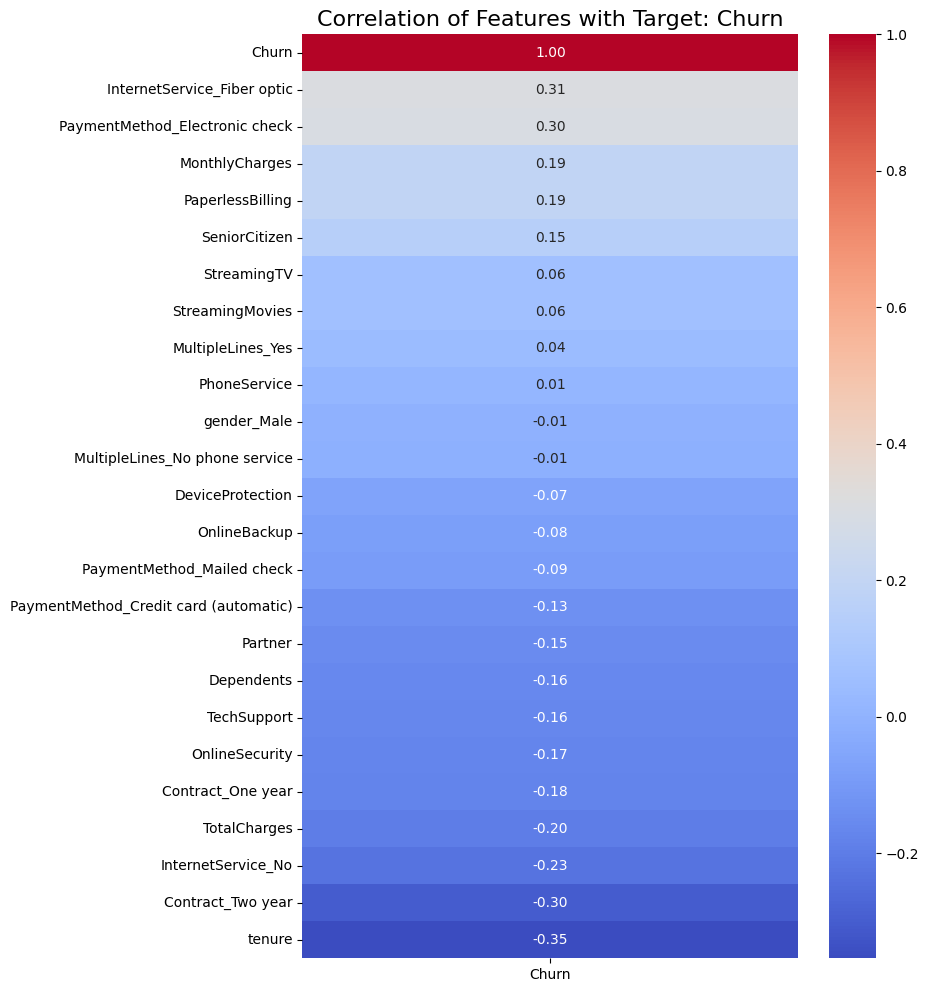

In [83]:
df=telecom_cust_dummies
correlation_matrix = df.corr()
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
churn_corr_df = pd.DataFrame(churn_corr)
plt.figure(figsize=(8, 12))
sns.heatmap(
    churn_corr_df,
    annot=True,              # Show the correlation value on the map
    cmap='coolwarm',         # Color scheme (e.g., 'coolwarm', 'viridis')
    fmt=".2f",               # Format to 2 decimal places
    cbar=True                # Show the color bar
)
plt.title('Correlation of Features with Target: Churn', fontsize=16)
plt.show()


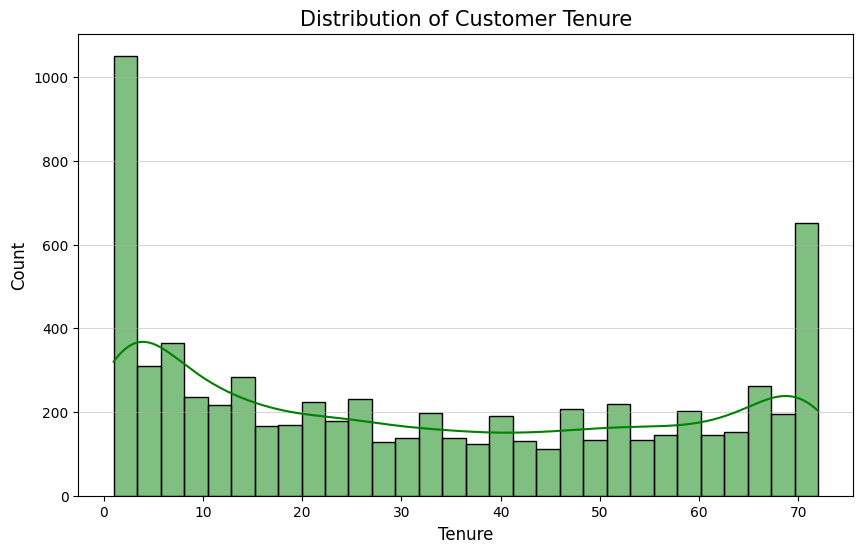

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(df['tenure'], bins=30, kde=True, color='green') 

plt.title('Distribution of Customer Tenure', fontsize=15)
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.savefig('tenure_histogram.png')
plt.show()


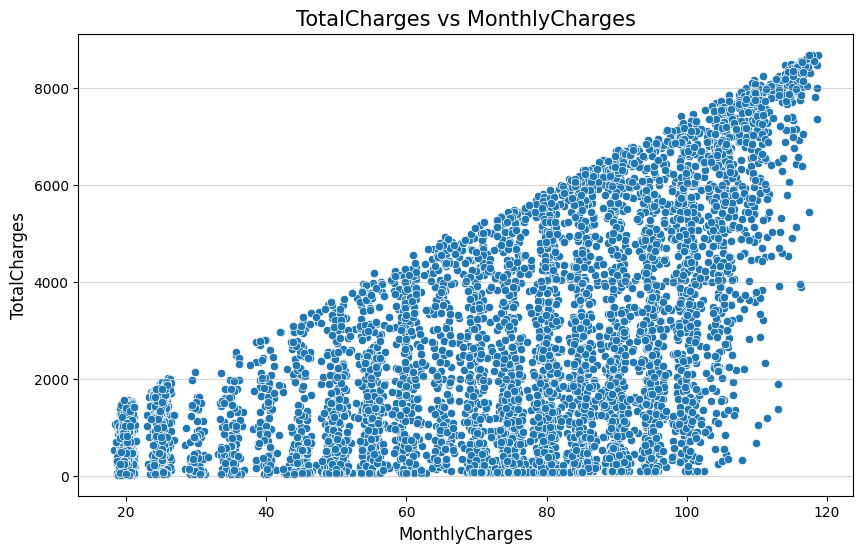

In [85]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges")

plt.title('TotalCharges vs MonthlyCharges', fontsize=15)
plt.xlabel('MonthlyCharges', fontsize=12)
plt.ylabel('TotalCharges', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.savefig('TotalCharges_MonthlyCharges.png')
plt.show()

C:\Users\ivano\AppData\Local\Temp\ipykernel_23824\3826412772.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


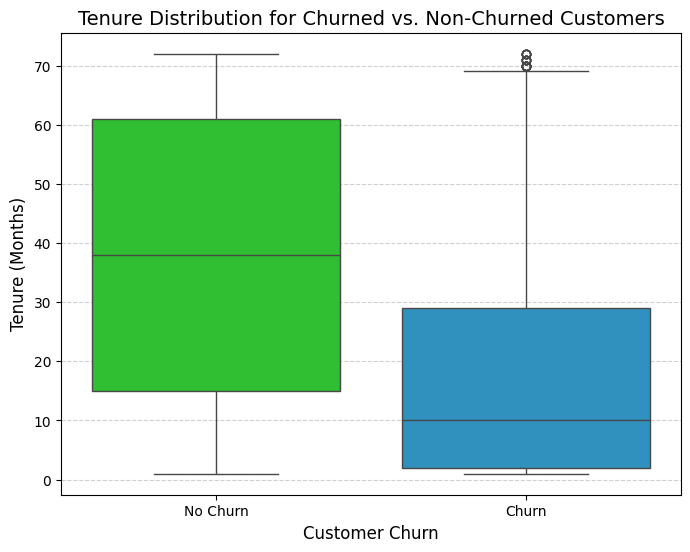

In [86]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Churn',             
    y='tenure',            
    data=df,
    palette=['#18d61b', '#189ad6'] 
)


plt.title('Tenure Distribution for Churned vs. Non-Churned Customers', fontsize=14)
plt.xlabel('Customer Churn', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn']) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [87]:
#Scale All the variables to range of 0 to 1
cols_to_scale = ['MonthlyCharges', 'TotalCharges', 'tenure']
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


In [88]:
#split data into training and test sets withg test size of 25%
y=df["Churn"]
X = df.drop(columns='Churn')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Logistic Regression

In [89]:
model = LogisticRegression(solver='liblinear',penalty='l2')
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [90]:
y_pred=model.predict(X_test)

#calculate accuracy score
Accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy = {Accuracy}')

Accuracy = 0.7912400455062572


## Random Forest Model

In [91]:
#start defining the hyperparameters
n_estimators_value = 2000
oob_score_value= True
max_feature_value = 'sqrt'
bootstrap = True
max_leaf_nodes_value = 50

rf_model = RandomForestClassifier(
    n_estimators=n_estimators_value,
    oob_score= oob_score_value,
    max_features=max_feature_value,
    max_leaf_nodes=max_leaf_nodes_value,
    bootstrap=bootstrap,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_y_pred= rf_model.predict(X_test)

#calculate accuracy score
Accuracy = accuracy_score(y_test,rf_y_pred)
print(f'Accuracy of Random Forest Model = {Accuracy}')


Accuracy of Random Forest Model = 0.7935153583617748


In [92]:
oob_score = rf_model.oob_score_
oob_error = 1- oob_score

print(f"OOB Score = {oob_score}")
print(f"OOB Error = {oob_error}")

OOB Score = 0.8062191884717482
OOB Error = 0.19378081152825177


The OOB Error is 0.19378. This value estimates how well the model will work for new unseen data. This means that when giving this model new data, you can expect it to be incorrect in the classification of the new data 19.38% of the time. This OOB error is generally considered good and the model looks like it did not suffer from overfitting

## Enhanced model evaluation

### Confusion Matrix

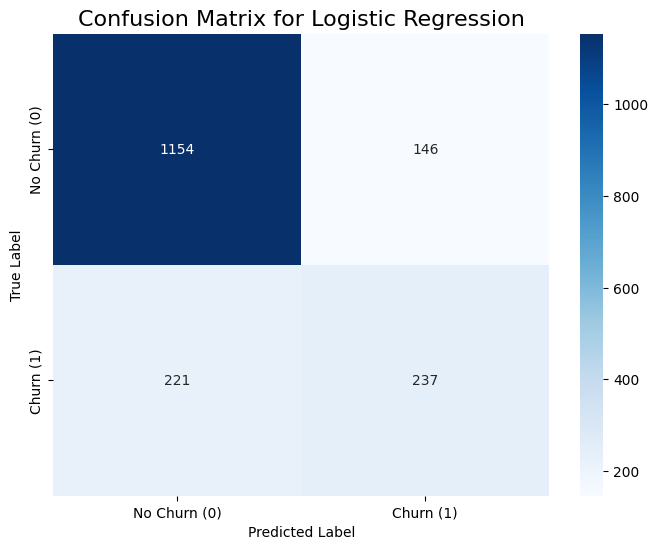


--- Results for Logistic Regression ---
True Negatives (TN): 1154 (Correctly predicted non-churn)
False Positives (FP): 146 (Incorrectly predicted churn)
False Negatives (FN): 221 (Incorrectly predicted non-churn)
True Positives (TP): 237 (Correctly predicted churn)
----------------------------------------


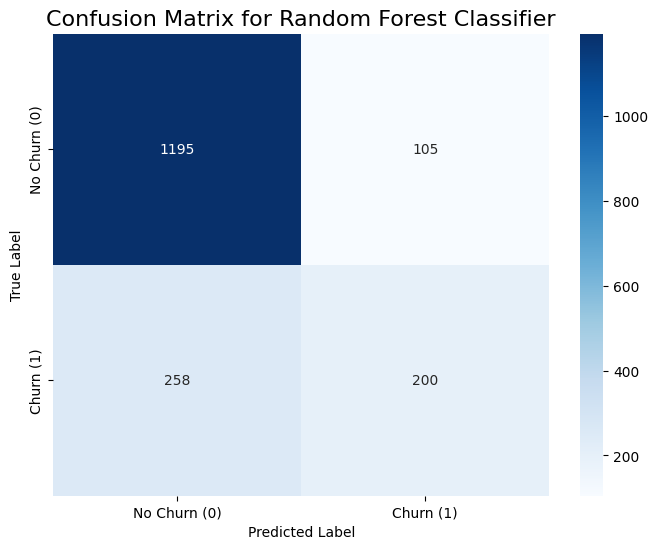


--- Results for Random Forest Classifier ---
True Negatives (TN): 1195 (Correctly predicted non-churn)
False Positives (FP): 105 (Incorrectly predicted churn)
False Negatives (FN): 258 (Incorrectly predicted non-churn)
True Positives (TP): 200 (Correctly predicted churn)
----------------------------------------


In [96]:
def plot_confusion_matrix(y_true, y_predicted, model_name):
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_true, y_predicted)
    
    labels = ['No Churn (0)', 'Churn (1)']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True,        
        fmt='d',           
        cmap='Blues',     
        cbar=True,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f'Confusion Matrix for {model_name}', fontsize=16)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Extract the four core values for printing
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    print(f"\n--- Results for {model_name} ---")
    print(f"True Negatives (TN): {TN} (Correctly predicted non-churn)")
    print(f"False Positives (FP): {FP} (Incorrectly predicted churn)")
    print(f"False Negatives (FN): {FN} (Incorrectly predicted non-churn)")
    print(f"True Positives (TP): {TP} (Correctly predicted churn)")
    print("-" * 40)

    return(TN,FP,FN,TP)



TN_Logistic,FP_Logistic,FN_Logistic,TP_Logistic=plot_confusion_matrix(y_test, y_pred, 'Logistic Regression')


TN_RF,FP_RF,FN_RF,TP_RF=plot_confusion_matrix(y_test, rf_y_pred, 'Random Forest Classifier')

### Calculate the Precision and Recall Scores

In [97]:
def precision_recall(TN,FP,FN,TP,model_name):
    #calculate the precision and the recall score of a model

    Precision = TP/(TP + FP)
    Recall = TP/(TP + FN)

    print(f'The Precision of the {model_name} model is: {Precision}')
    print(f'The Recall of the {model_name} model is: {Recall}')

precision_recall(TN_Logistic,FP_Logistic,FN_Logistic,TP_Logistic,"logistic regression")
precision_recall(TN_RF,FP_RF,FN_RF,TP_RF,"random forest")

The Precision of the logistic regression model is: 0.618798955613577
The Recall of the logistic regression model is: 0.517467248908297
The Precision of the random forest model is: 0.6557377049180327
The Recall of the random forest model is: 0.4366812227074236


### Confusion matrix and Precision and Recall results discussion  
Looking at the confusion matrix we can see the following:
Recall: The Logistic Regression model is better at predicting actual churning clients
Precision: Random Forest model has less False Positives  
Logistic Regression misses 37 fewer actual churners
The Random Forests model has 41 less False Positive values, meaning less clients would incorrectly be seen as possible churners.  
  
Logistic Regression is a more aggressive model and aims to find as many as possible actual churners even if it means that a few client who are not possible churners would also be flagged.  
Random Forests prioritises minimising the False Positives, meaning that it is more accurate in showing actual churners 
Both models 
Both the models are not that effective at predicting churners with Logistic Regression only getting 51.7% correct and Random Forest model only getting 43.7% of the churners correct. 


### Which model is more suitable for this specific task, and why?  
If the main task of the prediction model is for the use in campaigns to possible churning clients, the most expensive error is possible to miss clients with high risk of churning  on the model, then it would be better to use a more aggressive model even if it mean that some clients who were not churning risks will also be flagged. For this goal the Logistic Regression model is more effective. 